# Load Dataset

In [23]:
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes.csv")
head(data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


In [ ]:
Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"

In [ ]:
train_data <- read.csv("../Pima-Indians-Diabetes-Dataset/train_data.csv")
test_data <- read.csv("../Pima-Indians-Diabetes-Dataset/test_data.csv")

In [20]:
dim(train_data)
dim(test_data)

[1] 614   9

[1] 154   9

In [21]:
head(train_data)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,0,138,60,35,167,34.6,0.534,21,1
2,8,74,70,40,49,35.3,0.705,39,0
3,5,143,78,0,0,45.0,0.190,47,0
4,3,87,60,18,0,21.8,0.444,21,0
5,8,85,55,20,0,24.4,0.136,42,0
6,5,78,48,0,0,33.7,0.654,25,0


# Handle Missing Value
* *Glucose*
* *BloodPressure*
* *SkinThickness*
* *Insulin*
* *BMI*

### Hypothesis Test

In [24]:
test_skin_na <- t.test(SkinThickness ~ Outcome, data = data)
test_skin_na

test_bmi_na <- t.test(BMI ~ Outcome, data = data)
test_bmi_na

test_insulin_na <- t.test(Insulin ~ Outcome, data = data)
test_insulin_na

test_glucose_na <- t.test(Glucose ~ Outcome, data = data)
test_glucose_na

test_blood_na <- t.test(BloodPressure ~ Outcome, data = data)
test_blood_na


	Welch Two Sample t-test

data:  SkinThickness by Outcome
t = -1.9706, df = 472.1, p-value = 0.04936
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -4.993281565 -0.007076644
sample estimates:
mean in group 0 mean in group 1 
       19.66400        22.16418 



	Welch Two Sample t-test

data:  BMI by Outcome
t = -8.6193, df = 573.47, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -5.940864 -3.735811
sample estimates:
mean in group 0 mean in group 1 
       30.30420        35.14254 



	Welch Two Sample t-test

data:  Insulin by Outcome
t = -3.3009, df = 415.75, p-value = 0.001047
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -50.32820 -12.75944
sample estimates:
mean in group 0 mean in group 1 
        68.7920        100.3358 



	Welch Two Sample t-test

data:  Glucose by Outcome
t = -13.752, df = 461.33, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -35.74707 -26.80786
sample estimates:
mean in group 0 mean in group 1 
       109.9800        141.2575 



	Welch Two Sample t-test

data:  BloodPressure by Outcome
t = -1.7131, df = 471.31, p-value = 0.08735
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -5.669580  0.388326
sample estimates:
mean in group 0 mean in group 1 
       68.18400        70.82463 


### Boxplot

In [32]:
data_clean <- train_data
head(data_clean) 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,0,138,60,35,167,34.6,0.534,21,1
2,8,74,70,40,49,35.3,0.705,39,0
3,5,143,78,0,0,45.0,0.190,47,0
4,3,87,60,18,0,21.8,0.444,21,0
5,8,85,55,20,0,24.4,0.136,42,0
6,5,78,48,0,0,33.7,0.654,25,0


In [33]:
# Remove rows with Glucose = 0
data_glucose <- subset(data_clean, Glucose != 0)

# Remove rows with BloodPressure = 0
data_bp <- subset(data_clean, BloodPressure != 0)

# Remove rows with SkinThickness = 0
data_skin <- subset(data_clean, SkinThickness != 0)

# Remove rows with Insulin = 0
data_insulin <- subset(data_clean, Insulin != 0)

# Remove rows with BMI = 0
data_bmi <- subset(data_clean, BMI != 0)

In [34]:
cat("Original:", nrow(data_clean), "\n")
cat("Glucose:", nrow(data_glucose), "\n")
cat("BloodPressure:", nrow(data_bp), "\n")
cat("SkinThickness:", nrow(data_skin), "\n")
cat("Insulin:", nrow(data_insulin), "\n")
cat("BMI:", nrow(data_bmi), "\n")

Original: 614 
Glucose: 610 
BloodPressure: 586 
SkinThickness: 438 
Insulin: 322 
BMI: 606 


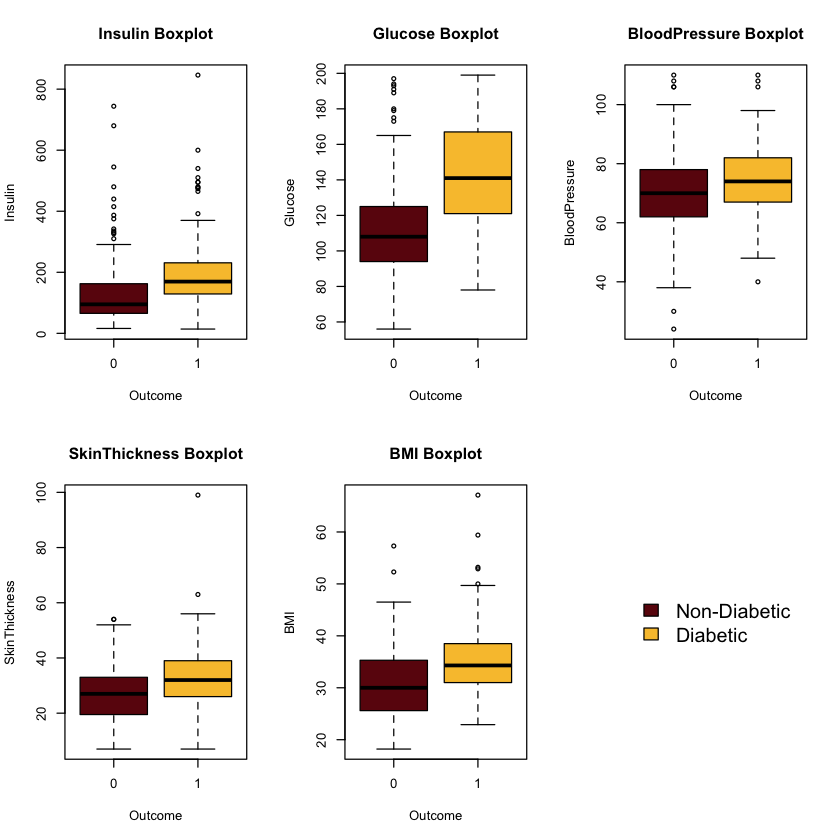

In [28]:
par(mfrow = c(2, 3), bg = "white")

boxplot(Insulin ~ Outcome,
        data = data_insulin,
        main = "Insulin Boxplot",
        xlab = "Outcome",
        ylab = "Insulin",
        col = c(Garnet, Gold))

boxplot(Glucose ~ Outcome,
        data = data_glucose,
        main = "Glucose Boxplot",
        xlab = "Outcome",
        ylab = "Glucose",
        col = c(Garnet, Gold))

boxplot(BloodPressure ~ Outcome,
        data = data_bp,
        main = "BloodPressure Boxplot",
        xlab = "Outcome",
        ylab = "BloodPressure",
        col = c(Garnet, Gold))

boxplot(SkinThickness ~ Outcome,
        data = data_skin,
        main = "SkinThickness Boxplot",
        xlab = "Outcome",
        ylab = "SkinThickness",
        col = c(Garnet, Gold))

boxplot(BMI ~ Outcome,
        data = data_bmi,
        main = "BMI Boxplot",
        xlab = "Outcome",
        ylab = "BMI",
        col = c(Garnet, Gold))

plot.new()

# Add legend only
legend(
  "center",
  legend = c("Non-Diabetic", "Diabetic"),
  fill = c(Garnet, Gold),
  bty = "n",
  cex = 1.5
)

### Mean

In [6]:
summary(train_data)

  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.:100.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :118.0   Median : 70.00   Median :23.00  
 Mean   : 3.793   Mean   :121.5   Mean   : 68.66   Mean   :20.79  
 3rd Qu.: 6.000   3rd Qu.:140.0   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :110.00   Max.   :99.00  
    Insulin            BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.00   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.00   1st Qu.:27.32   1st Qu.:0.2482           1st Qu.:24.00  
 Median : 41.00   Median :32.00   Median :0.3825           Median :29.00  
 Mean   : 81.63   Mean   :31.97   Mean   :0.4839           Mean   :33.18  
 3rd Qu.:130.00   3rd Qu.:36.58   3rd Qu.:0.6400           3rd Qu.:40.00  
 Max.   :846.00   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Ou

In [35]:
# ============================
# Check zeros before imputation
# ============================

cat("Zeros BEFORE imputation:\n")

colSums(
  train_data[, c(
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  )] == 0
)

Zeros BEFORE imputation:


Glucose BloodPressure SkinThickness       Insulin           BMI 
            4            28           176           292             8

In [8]:
# ============================
# Calculate means from TRAIN data
# ============================

mean_glucose_0 <- mean(train_data$Glucose[
  train_data$Outcome == 0 &
  train_data$Glucose != 0
])

mean_glucose_1 <- mean(train_data$Glucose[
  train_data$Outcome == 1 &
  train_data$Glucose != 0
])

mean_bp_0 <- mean(train_data$BloodPressure[
  train_data$Outcome == 0 &
  train_data$BloodPressure != 0
])

mean_bp_1 <- mean(train_data$BloodPressure[
  train_data$Outcome == 1 &
  train_data$BloodPressure != 0
])

mean_skin_0 <- mean(train_data$SkinThickness[
  train_data$Outcome == 0 &
  train_data$SkinThickness != 0
])

mean_skin_1 <- mean(train_data$SkinThickness[
  train_data$Outcome == 1 &
  train_data$SkinThickness != 0
])

mean_insulin_0 <- mean(train_data$Insulin[
  train_data$Outcome == 0 &
  train_data$Insulin != 0
])

mean_insulin_1 <- mean(train_data$Insulin[
  train_data$Outcome == 1 &
  train_data$Insulin != 0
])

mean_bmi_0 <- mean(train_data$BMI[
  train_data$Outcome == 0 &
  train_data$BMI != 0
])

mean_bmi_1 <- mean(train_data$BMI[
  train_data$Outcome == 1 &
  train_data$BMI != 0
])

print("Glucose 0 & 1")
mean_glucose_0
mean_glucose_1

print("BloodPressure 0 & 1")
mean_bp_0
mean_bp_1

print("SkinThickness 0 & 1")
mean_skin_0
mean_skin_1

print("Insulin 0 & 1")
mean_insulin_0
mean_insulin_1

print("BMI 0 & 1")
mean_bmi_0
mean_bmi_1

[1] "Glucose 0 & 1"


[1] 110.9848

[1] 143.2103

[1] "BloodPressure 0 & 1"


[1] 70.53665

...

[1] 129.3821

[1] 206.2818

[1] "BMI 0 & 1"


[1] 30.76122

[1] 35.3785

In [37]:
# ============================
# Impute TRAIN data
# ============================
# Glucose
train_data$Glucose[train_data$Outcome == 0 & train_data$Glucose == 0] <- mean_glucose_0
train_data$Glucose[train_data$Outcome == 1 & train_data$Glucose == 0] <- mean_glucose_1

# BloodPressure
train_data$BloodPressure[train_data$Outcome == 0 & train_data$BloodPressure == 0] <- mean_bp_0
train_data$BloodPressure[train_data$Outcome == 1 & train_data$BloodPressure == 0] <- mean_bp_1

# SkinThickness
train_data$SkinThickness[train_data$Outcome == 0 & train_data$SkinThickness == 0] <- mean_skin_0
train_data$SkinThickness[train_data$Outcome == 1 & train_data$SkinThickness == 0] <- mean_skin_1

# Insulin
train_data$Insulin[train_data$Outcome == 0 & train_data$Insulin == 0] <- mean_insulin_0
train_data$Insulin[train_data$Outcome == 1 & train_data$Insulin == 0] <- mean_insulin_1

# BMI
train_data$BMI[train_data$Outcome == 0 & train_data$BMI == 0] <- mean_bmi_0
train_data$BMI[train_data$Outcome == 1 & train_data$BMI == 0] <- mean_bmi_1


# ============================
# Impute TEST data
# ============================

# Glucose
test_data$Glucose[test_data$Outcome == 0 &
                  test_data$Glucose == 0] <- mean_glucose_0

test_data$Glucose[test_data$Outcome == 1 &
                  test_data$Glucose == 0] <- mean_glucose_1

# BloodPressure
test_data$BloodPressure[test_data$Outcome == 0 &
                        test_data$BloodPressure == 0] <- mean_bp_0

test_data$BloodPressure[test_data$Outcome == 1 &
                        test_data$BloodPressure == 0] <- mean_bp_1

# SkinThickness
test_data$SkinThickness[test_data$Outcome == 0 &
                        test_data$SkinThickness == 0] <- mean_skin_0

test_data$SkinThickness[test_data$Outcome == 1 &
                        test_data$SkinThickness == 0] <- mean_skin_1

# Insulin
test_data$Insulin[test_data$Outcome == 0 &
                  test_data$Insulin == 0] <- mean_insulin_0

test_data$Insulin[test_data$Outcome == 1 &
                  test_data$Insulin == 0] <- mean_insulin_1

# BMI
test_data$BMI[test_data$Outcome == 0 &
              test_data$BMI == 0] <- mean_bmi_0

test_data$BMI[test_data$Outcome == 1 &
              test_data$BMI == 0] <- mean_bmi_1

In [13]:
# ============================
# Predict using trained model
# ============================
model <- glm(Outcome ~., data = train_data, family = binomial)
summary(model)

bic_value <- BIC(model)
cat("\nBIC of the model: ", bic_value, "\n")


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_data)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -9.248094   0.930778  -9.936  < 2e-16 ***
Pregnancies               0.111406   0.036084   3.087  0.00202 ** 
Glucose                   0.030661   0.004444   6.899 5.23e-12 ***
BloodPressure            -0.007664   0.010024  -0.765  0.44453    
SkinThickness             0.038266   0.015405   2.484  0.01299 *  
Insulin                   0.007093   0.001741   4.075 4.60e-05 ***
BMI                       0.057155   0.020314   2.814  0.00490 ** 
DiabetesPedigreeFunction  0.639411   0.328280   1.948  0.05144 .  
Age                       0.011158   0.010776   1.035  0.30046    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 542.47  on 605  degrees of freedom
AIC: 560.


BIC of the model:  600.246 


In [14]:
# ============================
# Predict using trained model
# ============================

prob <- predict(
  model,
  newdata = test_data,
  type = "response"
)

pred <- ifelse(prob > 0.5, 1, 0)

# ============================
# Confusion Matrix
# ============================

conf_matrix <- table(
  Predicted = pred,
  Actual = test_data$Outcome
)

cat("\nConfusion Matrix:\n")
print(conf_matrix)

# ============================
# Metrics
# ============================

TP <- conf_matrix["1","1"]
TN <- conf_matrix["0","0"]
FP <- conf_matrix["1","0"]
FN <- conf_matrix["0","1"]

accuracy <- (TP + TN) / sum(conf_matrix)

precision <- TP / (TP + FP)

recall <- TP / (TP + FN)

f1 <- 2 * precision * recall /
      (precision + recall)

cat("\nAccuracy :", round(accuracy, 4))
cat("\nPrecision:", round(precision, 4))
cat("\nRecall   :", round(recall, 4))
cat("\nF1 Score :", round(f1, 4))


Confusion Matrix:
         Actual
Predicted  0  1
        0 90 21
        1 12 31

Accuracy : 0.7857
Precision: 0.7209
Recall   : 0.5962
F1 Score : 0.6526

### Save the imputed training and testing sets

In [39]:
# write.csv(train_data, "../Pima-Indians-Diabetes-Dataset/train_data_imputed.csv", row.names = FALSE)
# write.csv(test_data, "../Pima-Indians-Diabetes-Dataset/test_data_imputed.csv", row.names = FALSE)